# IFN680 Project 4 — Case 2: Eyeglasses Classifier Audit

## 1. Audit Objective

### Case context
An eyeglasses classifier developed for an automated retail kiosk achieved near-perfect performance during internal testing. Its performance was also reported to remain stable across changes in lighting and head pose. After deployment, however, the model performed reliably for some users while making substantially more errors for others, despite the external images remaining clear and visually similar to the internal data.

### Audit question
**Why does the eyeglasses classifier generalise poorly to some users in the external deployment data despite strong internal performance and apparently comparable image quality?**

### Initial hypothesis
Because the reported failures are user-dependent rather than obviously associated with image quality, lighting, or pose, the model may have learned a **spurious correlation** between the target attribute (eyeglasses) and another facial or demographic characteristic present in the development data.

If the internal dataset contains such a confounding relationship, the model may achieve very high internal accuracy by partially relying on a shortcut rather than consistently detecting eyeglasses themselves. Performance would then deteriorate when that relationship changes in the external population.

This is an **initial audit hypothesis only**. The final diagnosis will be based on measurable model behaviour and dataset evidence.

### Audit workflow
1. Load the supplied model and internal/external test datasets.
2. Inspect dataset size, class balance and representative images.
3. Reproduce baseline performance on both test sets.
4. Examine the pattern of external errors rather than relying only on aggregate accuracy.
5. Investigate whether performance differs systematically between identifiable subgroups.
6. Examine whether the development data contain a relationship between the target label and subgroup characteristics.
7. Use saliency / localisation analysis where useful to investigate which facial regions influence predictions.
8. Form an evidence-supported diagnosis and provide targeted recommendations.

> **Assessment principle:** poor external accuracy alone does not identify the root cause. The audit must establish what systematic relationship explains the errors and provide reproducible evidence for that conclusion.

## 2. Environment / Imports

The supplied starter notebook uses PyTorch / torchvision, NumPy, pandas, Matplotlib and scikit-learn. The same core environment is retained for this audit.

Random seeds are fixed for reproducibility. CUDA is used when available, with CPU as a fallback.

The final notebook is stored at the root of `project4_code/`, while all supplied Case 2 resources are stored inside the `Case2/` subdirectory.

In [1]:
from pathlib import Path
from collections import Counter
import random
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

import tqdm


# Reproducibility
SEED = 0

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)



# Device

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")



# Project paths
#
# Expected structure:
#
# project4_code/
# ├── case1.ipynb
# ├── case2.ipynb
# ├── case3.ipynb
# └── Case2/
#     ├── Case2Dataset.zip
#     ├── resnet_frozen_best-3.pth
#     └── student_start_notebook-5.ipynb

ROOT_DIR = Path.cwd()
CASE_DIR = ROOT_DIR / "Case2"

DATA_ZIP_PATH = CASE_DIR / "Case2Dataset.zip"
MODEL_PATH = CASE_DIR / "resnet_frozen_best-3.pth"

# Extracted data remain inside Case2 so the notebook can be rerun
# without depending on files elsewhere on the computer.
EXTRACT_DIR = CASE_DIR / "_extracted"


# Confirm that all required supplied files are available.
assert CASE_DIR.exists(), f"Case directory not found: {CASE_DIR}"
assert DATA_ZIP_PATH.exists(), f"Dataset ZIP not found: {DATA_ZIP_PATH}"
assert MODEL_PATH.exists(), f"Model weights not found: {MODEL_PATH}"

print(f"Case directory: {CASE_DIR}")
print(f"Dataset ZIP:    {DATA_ZIP_PATH}")
print(f"Model weights:  {MODEL_PATH}")

Using device: cuda:0
Case directory: /home/n10755306/ifn680/IFN680_Sam/Assessment1/Project4/Case2
Dataset ZIP:    /home/n10755306/ifn680/IFN680_Sam/Assessment1/Project4/Case2/Case2Dataset.zip
Model weights:  /home/n10755306/ifn680/IFN680_Sam/Assessment1/Project4/Case2/resnet_frozen_best-3.pth


## 3. Load Model

The supplied Case 2 starter notebook uses a **ResNet-18** architecture adapted for binary classification by replacing the final fully connected layer with two outputs.

The same architecture is reconstructed here and the supplied trained state dictionary is loaded without modifying or retraining the model.

`weights=None` is used when constructing the ResNet because the supplied `.pth` file immediately replaces the model parameters. This also avoids requiring an external ImageNet weights download when the notebook is executed in the IFN680 environment.

In [2]:
def setup_model(model, num_classes, freeze_backbone=False):
    """Adapt a torchvision ResNet classifier to the required number of classes."""
    
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    if freeze_backbone:
        for parameter in model.parameters():
            parameter.requires_grad = False

        # Keep the final classification layer trainable.
        for parameter in model.fc.parameters():
            parameter.requires_grad = True

    return model


# Recreate the architecture used by the supplied starter notebook.
backbone = torchvision.models.resnet18(weights=None)

resnet_frozen = setup_model(
    backbone,
    num_classes=2,
    freeze_backbone=False
)


# Load the supplied trained weights.
# weights_only=True is preferred when supported by the installed PyTorch version.
try:
    checkpoint = torch.load(
        MODEL_PATH,
        map_location=device,
        weights_only=True
    )
except TypeError:
    checkpoint = torch.load(
        MODEL_PATH,
        map_location=device
    )


# Support either a raw state_dict or a checkpoint containing a "state_dict" entry.
state_dict = (
    checkpoint["state_dict"]
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint
    else checkpoint
)

resnet_frozen.load_state_dict(state_dict)

resnet_frozen = resnet_frozen.to(device)
resnet_frozen.eval()

print("Model loaded successfully.")
print(f"Model type: {resnet_frozen.__class__.__name__}")
print(f"Output classes: {resnet_frozen.fc.out_features}")

Model loaded successfully.
Model type: ResNet
Output classes: 2


## 4. Load Internal Dataset

The internal test set represents the controlled development / "Lab Phase" distribution on which the eyeglasses classifier was reported to perform extremely well.

The supplied starter notebook uses `torchvision.datasets.ImageFolder`, so the class labels are obtained directly from the directory structure rather than being hard-coded.

The same ImageNet preprocessing used in the starter notebook is retained:

- input size = `224 × 224`
- mean = `(0.485, 0.456, 0.406)`
- standard deviation = `(0.229, 0.224, 0.225)`

A second raw version of the dataset is retained without normalisation so that images can later be inspected visually and analysed independently of the model preprocessing.

In [3]:
# Extract the supplied dataset ZIP

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Only extract when the directory is empty.
# This avoids unnecessary repeated extraction when rerunning the notebook.
if not any(EXTRACT_DIR.iterdir()):
    with zipfile.ZipFile(DATA_ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    print(f"Dataset extracted to: {EXTRACT_DIR}")
else:
    print(f"Using existing extracted dataset at: {EXTRACT_DIR}")


def find_unique_split(root: Path, split_name: str) -> Path:
    """Find exactly one real ImageFolder split beneath the extracted dataset."""

    matches = [
        path for path in root.rglob(split_name)
        if path.is_dir()
        and "__MACOSX" not in path.parts
    ]

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Could not find a directory named '{split_name}' beneath {root}"
        )

    if len(matches) > 1:
        raise RuntimeError(
            f"Found multiple valid directories named '{split_name}': {matches}"
        )

    return matches[0]


# Locate the internal test split without depending on the ZIP's outer folder name.
INTERNAL_DIR = find_unique_split(
    EXTRACT_DIR,
    "test_internal"
)

print(f"Internal split: {INTERNAL_DIR}")


# Model preprocessing from the supplied starter notebook

imagenet_means = (0.485, 0.456, 0.406)
imagenet_stds = (0.229, 0.224, 0.225)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.Normalize(imagenet_means, imagenet_stds),
])


# Raw dataset for visual inspection.
test_internal_raw = torchvision.datasets.ImageFolder(
    INTERNAL_DIR
)

# Transformed dataset for model inference.
test_internal_dataset = torchvision.datasets.ImageFolder(
    INTERNAL_DIR,
    transform=transform
)

batch_size = 16

test_internal_loader = torch.utils.data.DataLoader(
    test_internal_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print(f"Internal test dataset size: {len(test_internal_dataset)}")
print(f"Internal classes: {test_internal_dataset.classes}")
print(f"Internal class mapping: {test_internal_dataset.class_to_idx}")

Using existing extracted dataset at: /home/n10755306/ifn680/IFN680_Sam/Assessment1/Project4/Case2/_extracted
Internal split: /home/n10755306/ifn680/IFN680_Sam/Assessment1/Project4/Case2/_extracted/Case2Dataset/test_internal
Internal test dataset size: 300
Internal classes: ['negative', 'positive']
Internal class mapping: {'negative': 0, 'positive': 1}


## 5. Load External Dataset

The external test set represents the deployment distribution where the kiosk system exhibited user-dependent failures.

The external images are processed using exactly the same pipeline as the internal images. This ensures that any subsequent performance difference reflects model behaviour on the supplied datasets rather than inconsistencies introduced by the audit implementation.

A raw version is again retained for visual inspection and subgroup analysis.

In [4]:
# Locate the external test split.
EXTERNAL_DIR = find_unique_split(
    EXTRACT_DIR,
    "test_external"
)

print(f"External split: {EXTERNAL_DIR}")


# Raw copy for visual and dataset inspection.
test_external_raw = torchvision.datasets.ImageFolder(
    EXTERNAL_DIR
)

# Transformed copy for model inference.
test_external_dataset = torchvision.datasets.ImageFolder(
    EXTERNAL_DIR,
    transform=transform
)

test_external_loader = torch.utils.data.DataLoader(
    test_external_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print(f"External test dataset size: {len(test_external_dataset)}")
print(f"External classes: {test_external_dataset.classes}")
print(f"External class mapping: {test_external_dataset.class_to_idx}")


# Direct performance comparison requires identical class-index mappings.
assert test_internal_dataset.class_to_idx == test_external_dataset.class_to_idx, (
    "Internal and external class mappings differ. "
    "Do not compare model outputs until this is resolved."
)

class_names = test_internal_dataset.classes
class_to_idx = test_internal_dataset.class_to_idx

print("\nClass mappings are consistent across both test sets.")

External split: /home/n10755306/ifn680/IFN680_Sam/Assessment1/Project4/Case2/_extracted/Case2Dataset/test_external
External test dataset size: 300
External classes: ['negative', 'positive']
External class mapping: {'negative': 0, 'positive': 1}

Class mappings are consistent across both test sets.


## 6. Dataset Inspection

Before examining model performance, the internal and external datasets are compared descriptively.

This section first establishes:

1. dataset size;
2. class balance;
3. class-label consistency; and
4. representative images from each split and target class.

The case description states that the external failures occur despite images remaining clear and well-lit. Therefore, the audit should not assume a conventional image-quality shift without evidence. Instead, visual inspection will also be used to identify whether another systematic characteristic differs between the target classes or between the internal and external datasets.

Any apparent relationship observed visually is treated only as a hypothesis until it is tested quantitatively against model predictions.

### 6.1 Dataset size and class balance

Aggregate accuracy can be misleading when datasets have different target-class proportions. We therefore verify the number and proportion of positive and negative examples in each test set before comparing performance.

In [5]:
def summarise_class_balance(dataset, split_name):
    """Return class counts and proportions for an ImageFolder dataset."""
    
    target_counts = Counter(dataset.targets)
    total_samples = len(dataset)

    records = []

    for class_index, class_name in enumerate(dataset.classes):
        class_count = target_counts[class_index]

        records.append({
            "split": split_name,
            "class_index": class_index,
            "class_name": class_name,
            "count": class_count,
            "proportion": class_count / total_samples,
        })

    return records


class_balance = pd.DataFrame(
    summarise_class_balance(test_internal_dataset, "internal")
    + summarise_class_balance(test_external_dataset, "external")
)

class_balance

,split,class_index,class_name,count,proportion
0,internal,0,negative,150,0.5
1,internal,1,positive,150,0.5
2,external,0,negative,150,0.5
3,external,1,positive,150,0.5


### 6.2 Representative image inspection

Representative raw images are inspected from each combination of dataset split and target class.

The purpose of this inspection is not to diagnose the model from a few examples. Instead, it is used to identify systematic dataset characteristics that may justify a more targeted quantitative investigation.

For the eyeglasses task:

- `negative` = no eyeglasses
- `positive` = eyeglasses

Particular attention is given to whether characteristics unrelated to eyeglasses appear associated with the target label in the internal dataset, and whether those relationships remain the same in the external dataset.

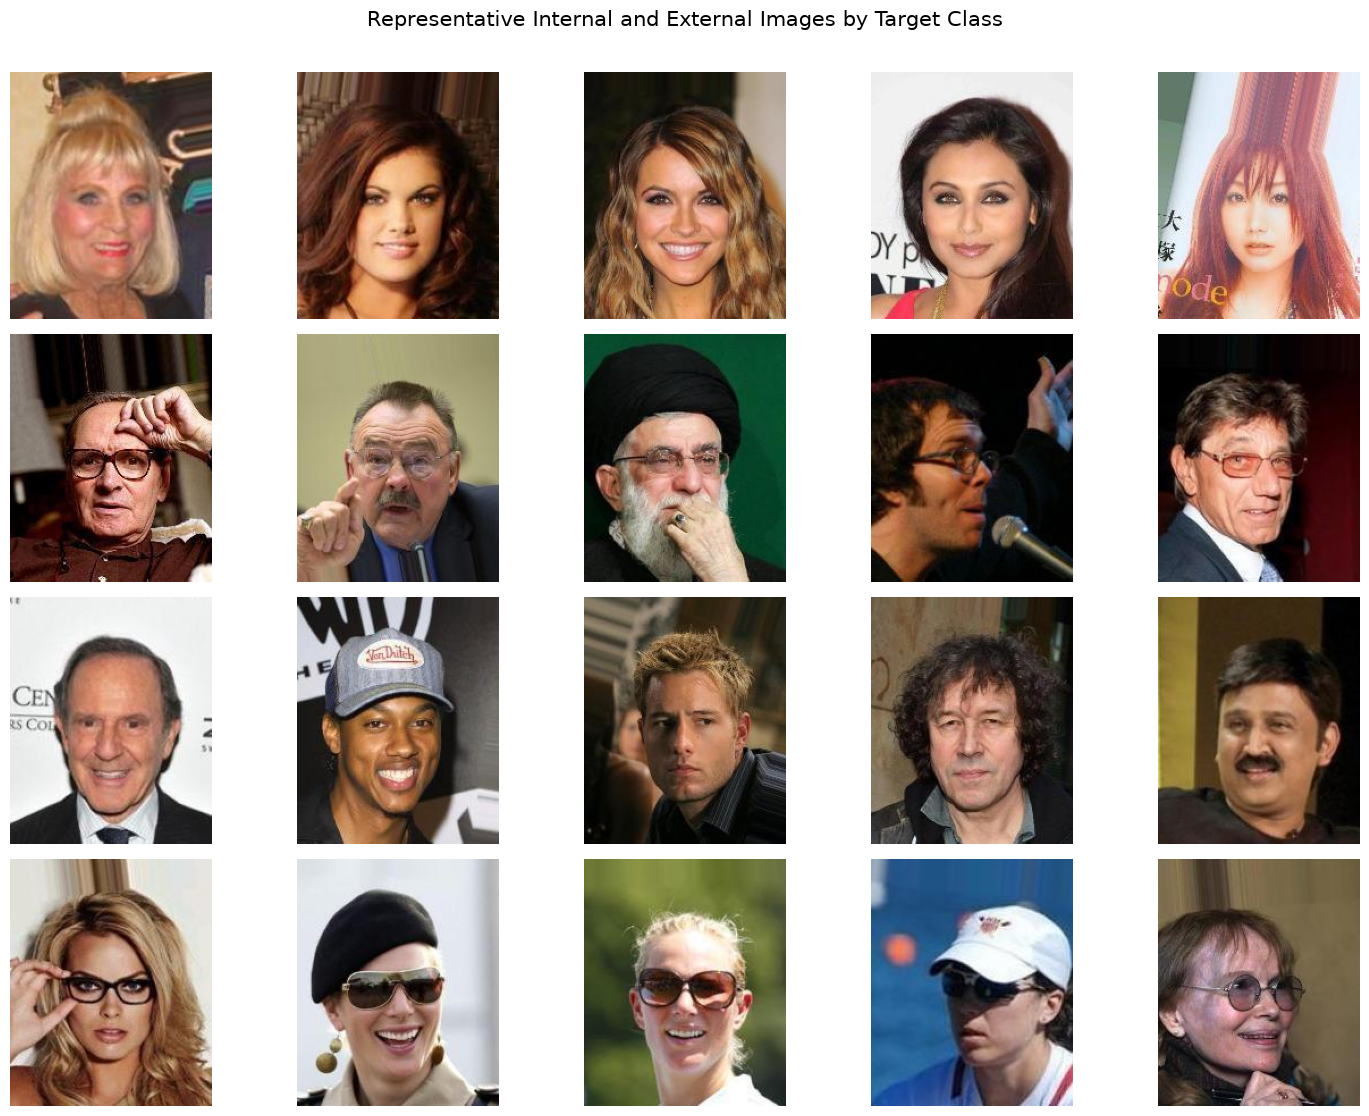

In [6]:
def show_representative_images(
    internal_dataset,
    external_dataset,
    examples_per_group=5,
    seed=SEED
):
    """Display reproducible raw examples from each split and target class."""

    rng = random.Random(seed)

    dataset_groups = [
        ("Internal — Negative", internal_dataset, 0),
        ("Internal — Positive", internal_dataset, 1),
        ("External — Negative", external_dataset, 0),
        ("External — Positive", external_dataset, 1),
    ]

    fig, axes = plt.subplots(
        len(dataset_groups),
        examples_per_group,
        figsize=(15, 11)
    )

    for row_index, (group_name, dataset, target_class) in enumerate(dataset_groups):

        # Find all samples belonging to the required target class.
        matching_indices = [
            index
            for index, target in enumerate(dataset.targets)
            if target == target_class
        ]

        selected_indices = rng.sample(
            matching_indices,
            examples_per_group
        )

        for column_index, sample_index in enumerate(selected_indices):
            image, label = dataset[sample_index]

            axes[row_index, column_index].imshow(image)
            axes[row_index, column_index].axis("off")

            if column_index == 0:
                axes[row_index, column_index].set_ylabel(
                    group_name,
                    fontsize=11
                )

    fig.suptitle(
        "Representative Internal and External Images by Target Class",
        fontsize=15,
        y=1.01
    )

    plt.tight_layout()
    plt.show()


show_representative_images(
    test_internal_raw,
    test_external_raw
)

## 7. Baseline Model Evaluation

The supplied model is evaluated without modification on both test sets.

Although overall accuracy provides the first indication of generalisation performance, binary classification metrics are also calculated separately for each target class. This is important because similar aggregate accuracy can conceal substantially different false-positive and false-negative behaviour.

For each dataset, the audit records:

- accuracy;
- precision;
- recall;
- F1-score;
- confusion matrix; and
- predicted probabilities for later error and subgroup analysis.

The same model, preprocessing and decision rule are used for both datasets.

In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

In [8]:
def evaluate_classifier(model, dataloader, device, split_name):
    """
    Evaluate the classifier and retain sample-level outputs for later auditing.

    Returns:
        Dictionary containing labels, predicted classes, probabilities,
        confidence scores, overall metrics and confusion matrix.
    """

    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for inputs, labels in tqdm.tqdm(
            dataloader,
            desc=f"Evaluating {split_name}"
        ):
            inputs = inputs.to(device)
            labels = labels.to(device)

            logits = model(inputs)
            probabilities = torch.softmax(logits, dim=1)
            predictions = torch.argmax(probabilities, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    labels_array = np.asarray(all_labels)
    predictions_array = np.asarray(all_predictions)
    probabilities_array = np.asarray(all_probabilities)

    metrics = {
        "accuracy": accuracy_score(
            labels_array,
            predictions_array
        ),
        "precision": precision_score(
            labels_array,
            predictions_array,
            zero_division=0
        ),
        "recall": recall_score(
            labels_array,
            predictions_array,
            zero_division=0
        ),
        "f1": f1_score(
            labels_array,
            predictions_array,
            zero_division=0
        ),
    }

    return {
        "split": split_name,
        "labels": labels_array,
        "predictions": predictions_array,
        "probabilities": probabilities_array,
        "confidence": probabilities_array.max(axis=1),
        "metrics": metrics,
        "confusion_matrix": confusion_matrix(
            labels_array,
            predictions_array
        ),
    }

In [9]:
internal_results = evaluate_classifier(
    resnet_frozen,
    test_internal_loader,
    device,
    "internal"
)

external_results = evaluate_classifier(
    resnet_frozen,
    test_external_loader,
    device,
    "external"
)

print("\nEvaluation complete.")

Evaluating external: 100%|██████████| 19/19 [00:01<00:00, 13.20it/s]


Evaluation complete.


In [10]:
performance_summary = pd.DataFrame([
    {
        "split": "internal",
        **internal_results["metrics"],
    },
    {
        "split": "external",
        **external_results["metrics"],
    }
])

performance_summary

,split,accuracy,precision,recall,f1
0,internal,0.986667,1.000000,0.973333,0.986486
1,external,0.710000,0.756098,0.620000,0.681319


### 7.1 Baseline performance comparison

The baseline evaluation establishes whether the field failure can be reproduced using the supplied model and datasets.

A substantial difference between internal and external performance would demonstrate a generalisation failure, but it would not by itself establish its cause. Subsequent sections therefore analyse the structure of the model's errors and the characteristics of the affected samples.

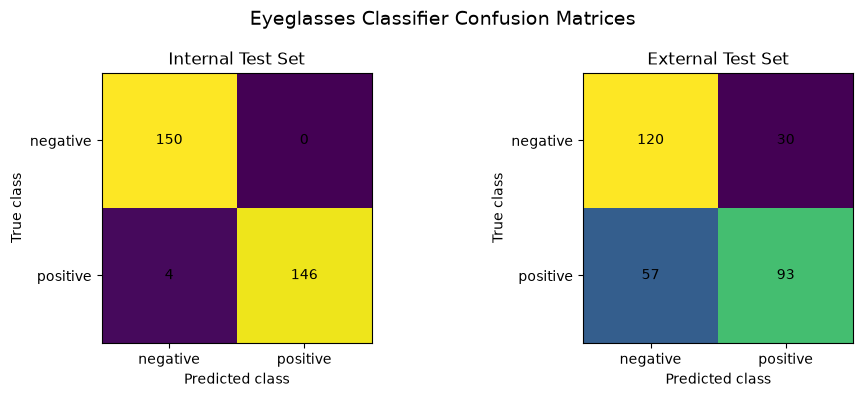

In [11]:
def plot_confusion_matrix(ax, matrix, title, class_names):
    """Plot a simple labelled confusion matrix."""

    image = ax.imshow(matrix)

    ax.set_title(title)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")

    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))

    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)

    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            ax.text(
                column,
                row,
                matrix[row, column],
                ha="center",
                va="center"
            )


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_confusion_matrix(
    axes[0],
    internal_results["confusion_matrix"],
    "Internal Test Set",
    class_names
)

plot_confusion_matrix(
    axes[1],
    external_results["confusion_matrix"],
    "External Test Set",
    class_names
)

fig.suptitle(
    "Eyeglasses Classifier Confusion Matrices",
    fontsize=14
)

plt.tight_layout()
plt.show()

### 7.2 Baseline findings

The supplied model reproduces the reported deployment failure.

Internal accuracy is **98.67%**, with only four misclassifications among 300 images. In contrast, external accuracy falls to **71.00%**, producing 87 errors.

The deterioration affects both classes:

- 30 external images without eyeglasses are incorrectly classified as positive;
- 57 external images with eyeglasses are incorrectly classified as negative;
- positive-class recall falls from **97.33% internally to 62.00% externally**.

Because both datasets are equally balanced between positive and negative target classes, this reduction cannot be explained by a change in class prevalence.

The baseline therefore establishes a substantial **generalisation failure**, but does not yet establish its cause. The next stage investigates whether the errors are systematically associated with characteristics of the people represented in the images.

## 8. Error Pattern Investigation

The aggregate metrics establish that performance deteriorates externally, but they do not show whether the 87 errors are randomly distributed across users.

A sample-level audit table is therefore constructed by linking each image to its true label, model prediction, predicted probability and error type.

Representative true positives, true negatives, false positives and false negatives can then be inspected for systematic characteristics unrelated to the eyeglasses target.

In [12]:
def build_audit_dataframe(dataset, results, split_name):
    """Create a sample-level dataframe linking images to model outputs."""

    assert len(dataset.samples) == len(results["labels"])

    records = []

    for index, ((image_path, dataset_target), true_label, predicted_label) in enumerate(
        zip(
            dataset.samples,
            results["labels"],
            results["predictions"]
        )
    ):
        # Confirm ImageFolder ordering matches the evaluated dataset.
        assert dataset_target == true_label

        probability_negative = results["probabilities"][index, 0]
        probability_positive = results["probabilities"][index, 1]

        if true_label == 0 and predicted_label == 0:
            error_type = "TN"
        elif true_label == 0 and predicted_label == 1:
            error_type = "FP"
        elif true_label == 1 and predicted_label == 0:
            error_type = "FN"
        else:
            error_type = "TP"

        records.append({
            "split": split_name,
            "sample_index": index,
            "filename": Path(image_path).name,
            "image_path": image_path,
            "true_label": int(true_label),
            "true_class": class_names[true_label],
            "predicted_label": int(predicted_label),
            "predicted_class": class_names[predicted_label],
            "prob_negative": probability_negative,
            "prob_positive": probability_positive,
            "confidence": results["confidence"][index],
            "correct": bool(true_label == predicted_label),
            "error_type": error_type,
        })

    return pd.DataFrame(records)


internal_audit = build_audit_dataframe(
    test_internal_dataset,
    internal_results,
    "internal"
)

external_audit = build_audit_dataframe(
    test_external_dataset,
    external_results,
    "external"
)

print(f"Internal records: {len(internal_audit)}")
print(f"External records: {len(external_audit)}")

external_audit.head()

Internal records: 300
External records: 300


,split,sample_index,filename,image_path,true_label,true_class,predicted_label,predicted_class,prob_negative,prob_positive,confidence,correct,error_type
0,external,0,10065.jpg,/home/n10755306/ifn680/IFN680_Sam/Assessment1/...,0,negative,0,negative,0.922684,0.077316,0.922684,True,TN
1,external,1,10083.jpg,/home/n10755306/ifn680/IFN680_Sam/Assessment1/...,0,negative,0,negative,0.991030,0.008970,0.991030,True,TN
2,external,2,10117.jpg,/home/n10755306/ifn680/IFN680_Sam/Assessment1/...,0,negative,0,negative,0.929211,0.070789,0.929211,True,TN
3,external,3,10185.jpg,/home/n10755306/ifn680/IFN680_Sam/Assessment1/...,0,negative,0,negative,0.780623,0.219377,0.780623,True,TN
4,external,4,10275.jpg,/home/n10755306/ifn680/IFN680_Sam/Assessment1/...,0,negative,0,negative,0.508651,0.491349,0.508651,True,TN


In [13]:
error_summary = pd.DataFrame({
    "internal": internal_audit["error_type"].value_counts(),
    "external": external_audit["error_type"].value_counts(),
}).fillna(0).astype(int)

error_summary = error_summary.reindex(
    ["TN", "FP", "FN", "TP"],
    fill_value=0
)

error_summary

,internal,external
error_type,,
TN,150,120
FP,0,30
FN,4,57
TP,146,93


### 8.1 Visual inspection of correct and incorrect external predictions

Representative external predictions are grouped by confusion-matrix outcome.

If the deployment errors are random, false positives and false negatives should not consistently differ from correctly classified examples in characteristics unrelated to eyeglasses.

Conversely, if errors concentrate within particular appearance subgroups, this would provide evidence that the model has learned a relationship that does not generalise uniformly across users.

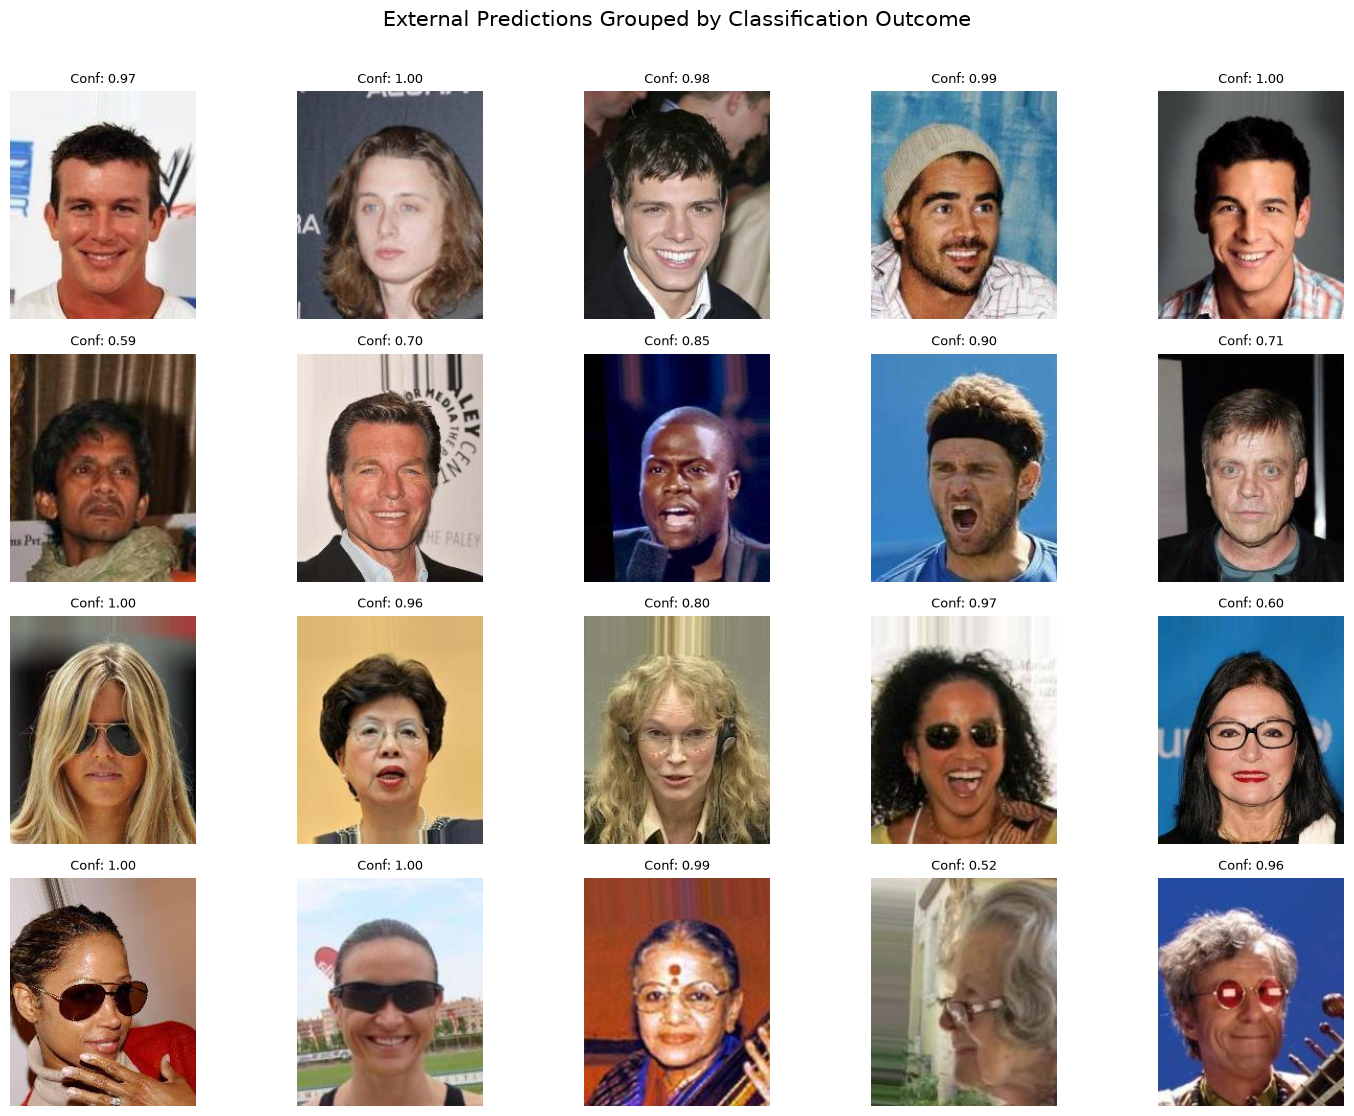

In [14]:
def show_prediction_groups(
    audit_dataframe,
    examples_per_group=5,
    seed=SEED
):
    """Display representative images from each confusion-matrix outcome."""

    rng = random.Random(seed)

    groups = [
        ("True Negative", "TN"),
        ("False Positive", "FP"),
        ("False Negative", "FN"),
        ("True Positive", "TP"),
    ]

    fig, axes = plt.subplots(
        len(groups),
        examples_per_group,
        figsize=(15, 11)
    )

    for row_index, (group_title, error_type) in enumerate(groups):

        group_rows = audit_dataframe[
            audit_dataframe["error_type"] == error_type
        ]

        number_to_sample = min(
            examples_per_group,
            len(group_rows)
        )

        selected_indices = rng.sample(
            list(group_rows.index),
            number_to_sample
        )

        for column_index in range(examples_per_group):
            ax = axes[row_index, column_index]
            ax.axis("off")

            if column_index >= number_to_sample:
                continue

            row = audit_dataframe.loc[
                selected_indices[column_index]
            ]

            image = Image.open(
                row["image_path"]
            ).convert("RGB")

            ax.imshow(image)

            ax.set_title(
                f"Conf: {row['confidence']:.2f}",
                fontsize=9
            )

            if column_index == 0:
                ax.set_ylabel(
                    f"{group_title}\n({error_type})",
                    fontsize=11
                )

    fig.suptitle(
        "External Predictions Grouped by Classification Outcome",
        fontsize=15,
        y=1.01
    )

    plt.tight_layout()
    plt.show()


show_prediction_groups(external_audit)

### 8.2 Class Activation Mapping (CAM)

The external error analysis shows that misclassifications are systematic rather than isolated. The next experiment investigates **which image regions influence the model's decisions**.

Class Activation Mapping (CAM) combines:

1. the feature maps produced by the final convolutional stage; and
2. the class-specific weights of the final linear classifier.

The resulting heatmap highlights regions that contribute strongly to a particular prediction.

For an eyeglasses classifier, a well-generalising model would be expected to obtain substantial evidence from the **eye / eyeglasses region**. Consistent activation elsewhere on the face or surrounding image may indicate reliance on features that are correlated with the target in the development data but are not themselves eyeglasses.

To make the comparison reproducible, the highest-confidence example is selected from each external confusion-matrix category:

- true negative (TN);
- false positive (FP);
- false negative (FN); and
- true positive (TP).

CAM is computed for the **class actually predicted by the model**.

In [15]:
def select_high_confidence_examples(audit_dataframe):
    """Select the highest-confidence sample from each prediction outcome."""

    selected_samples = {}

    for error_type in ["TN", "FP", "FN", "TP"]:
        group = audit_dataframe[
            audit_dataframe["error_type"] == error_type
        ]

        if len(group) == 0:
            continue

        selected_samples[error_type] = (
            group
            .sort_values("confidence", ascending=False)
            .iloc[0]
        )

    return selected_samples


selected_cam_samples = select_high_confidence_examples(
    external_audit
)

cam_selection_summary = pd.DataFrame([
    {
        "error_type": error_type,
        "filename": row["filename"],
        "true_class": row["true_class"],
        "predicted_class": row["predicted_class"],
        "confidence": row["confidence"],
    }
    for error_type, row in selected_cam_samples.items()
])

cam_selection_summary

,error_type,filename,true_class,predicted_class,confidence
0,TN,3013.jpg,negative,negative,0.999993
1,FP,8823.jpg,negative,positive,0.985085
2,FN,8844.jpg,positive,negative,0.999705
3,TP,1407.jpg,positive,positive,0.998529


In [16]:
# Storage for the output of the final ResNet convolutional stage.
cam_activations = {}


def capture_activation(name):
    """Create a forward hook that stores convolutional feature maps."""

    def hook(model, inputs, output):
        cam_activations[name] = output.detach()

    return hook


def compute_cam(model, image_tensor, predicted_class):
    """
    Compute a Class Activation Map for one image and predicted class.

    ResNet-18 applies global average pooling to the output of layer4
    before the final linear classifier, making standard CAM applicable.
    """

    model.eval()

    # Capture the feature maps immediately before global average pooling.
    hook_handle = model.layer4[1].register_forward_hook(
        capture_activation("layer4")
    )

    with torch.no_grad():
        logits = model(
            image_tensor.unsqueeze(0).to(device)
        )

    # Shape: [channels, height, width]
    feature_maps = cam_activations["layer4"][0]

    # Class-specific weights from the final linear classifier.
    class_weights = model.fc.weight[
        predicted_class
    ].detach()

    # Weighted combination of feature maps.
    cam = torch.sum(
        class_weights[:, None, None] * feature_maps,
        dim=0
    )

    # Retain positive evidence for the predicted class.
    cam = torch.clamp(cam, min=0)

    # Normalise the map to [0, 1].
    if torch.max(cam) > 0:
        cam = cam / torch.max(cam)

    # Resize the low-resolution CAM to the model input resolution.
    cam = torch.nn.functional.interpolate(
        cam.unsqueeze(0).unsqueeze(0),
        size=(
            image_tensor.shape[1],
            image_tensor.shape[2]
        ),
        mode="bilinear",
        align_corners=False
    )

    cam = (
        cam
        .squeeze()
        .cpu()
        .numpy()
    )

    # Remove the hook so repeated calls do not accumulate hooks.
    hook_handle.remove()

    return cam

In [17]:
def denormalise_image(image_tensor):
    """Convert an ImageNet-normalised tensor back to displayable RGB."""

    image = (
        image_tensor
        .detach()
        .cpu()
        .numpy()
        .transpose(1, 2, 0)
    )

    image = (
        image * np.asarray(imagenet_stds)
        + np.asarray(imagenet_means)
    )

    return np.clip(image, 0, 1)

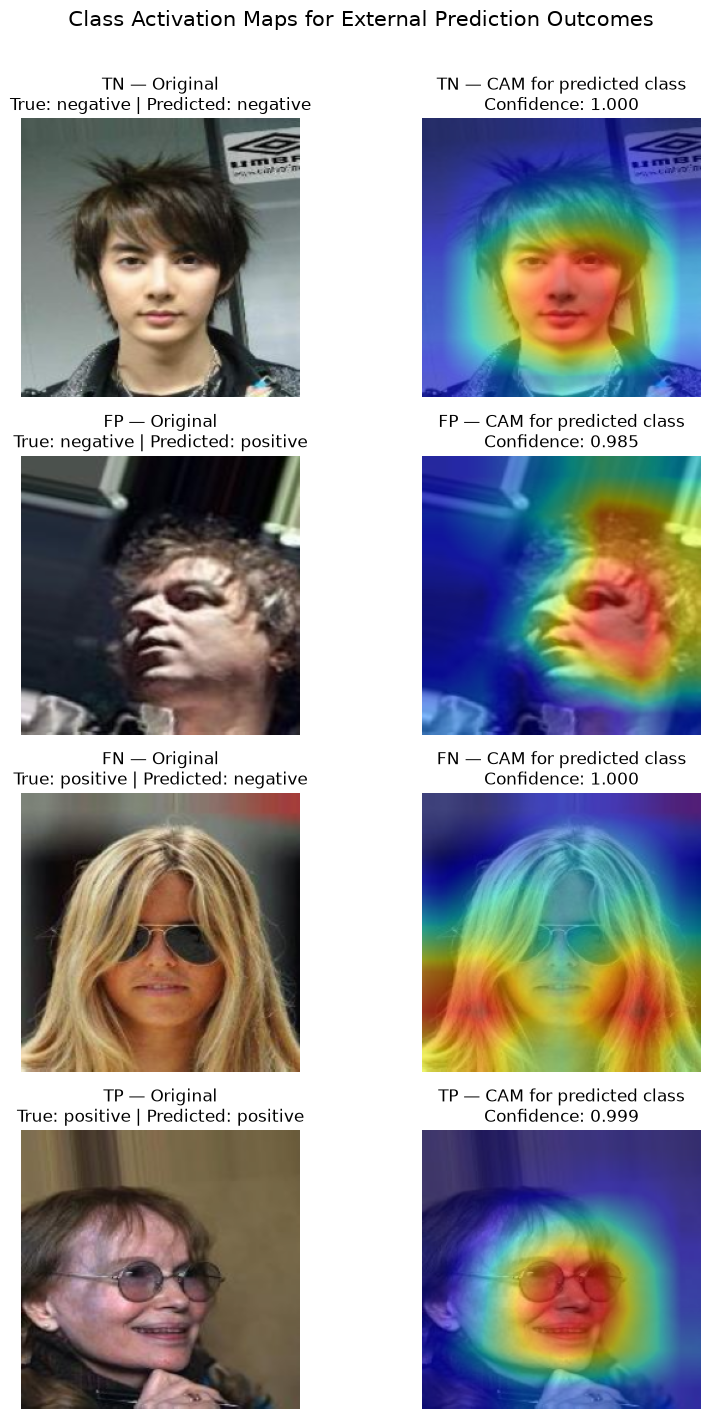

In [18]:
fig, axes = plt.subplots(
    len(selected_cam_samples),
    2,
    figsize=(9, 14)
)

for row_index, (error_type, sample) in enumerate(
    selected_cam_samples.items()
):
    sample_index = int(sample["sample_index"])

    image_tensor, true_label = test_external_dataset[
        sample_index
    ]

    predicted_class = int(
        sample["predicted_label"]
    )

    image_display = denormalise_image(
        image_tensor
    )

    cam = compute_cam(
        resnet_frozen,
        image_tensor,
        predicted_class
    )

    # Original image
    axes[row_index, 0].imshow(
        image_display
    )

    axes[row_index, 0].set_title(
        f"{error_type} — Original\n"
        f"True: {sample['true_class']} | "
        f"Predicted: {sample['predicted_class']}"
    )

    axes[row_index, 0].axis("off")

    # CAM overlay
    axes[row_index, 1].imshow(
        image_display
    )

    axes[row_index, 1].imshow(
        cam,
        alpha=0.5,
        cmap="jet"
    )

    axes[row_index, 1].set_title(
        f"{error_type} — CAM for predicted class\n"
        f"Confidence: {sample['confidence']:.3f}"
    )

    axes[row_index, 1].axis("off")


fig.suptitle(
    "Class Activation Maps for External Prediction Outcomes",
    fontsize=15,
    y=1.01
)

plt.tight_layout()
plt.show()

### 8.3 Controlled regional occlusion experiment

The CAM examples suggest that correct positive predictions can rely strongly on the eye / eyeglasses region, while some external errors are influenced by broader facial regions.

CAM is descriptive, however, and does not demonstrate that these regions causally affect the prediction.

A controlled occlusion experiment is therefore performed. Three approximately aligned facial regions are masked independently:

1. **upper face / hair**;
2. **eye / eyeglasses region**; and
3. **lower face**.

CelebA facial images are approximately aligned, allowing the same relative regions to be applied consistently after resizing to `224 × 224`.

Rather than replacing pixels with black, masked pixels are set to zero **after ImageNet normalisation**, corresponding approximately to the ImageNet mean colour. This reduces the introduction of an extreme artificial feature.

For each image, the probability assigned to the model's **originally predicted class** is recorded before and after each occlusion.

A large confidence reduction indicates that the masked region contained evidence important to the original decision.

In [19]:
# Approximate regions in the model's 224 x 224 input space.
# CelebA faces are approximately aligned, so fixed relative regions can
# provide a controlled comparison across the dataset.

OCCLUSION_REGIONS = {
    "upper_face_hair": {
        "x_start": 35,
        "x_end": 190,
        "y_start": 0,
        "y_end": 70,
    },
    "eye_region": {
        "x_start": 35,
        "x_end": 190,
        "y_start": 65,
        "y_end": 120,
    },
    "lower_face": {
        "x_start": 35,
        "x_end": 190,
        "y_start": 120,
        "y_end": 210,
    },
}


def occlude_tensor_region(image_tensor, region):
    """
    Return a copy of an ImageNet-normalised image tensor with one
    rectangular region replaced by the normalised mean value (zero).
    """

    occluded_image = image_tensor.clone()

    occluded_image[
        :,
        region["y_start"]:region["y_end"],
        region["x_start"]:region["x_end"]
    ] = 0.0

    return occluded_image

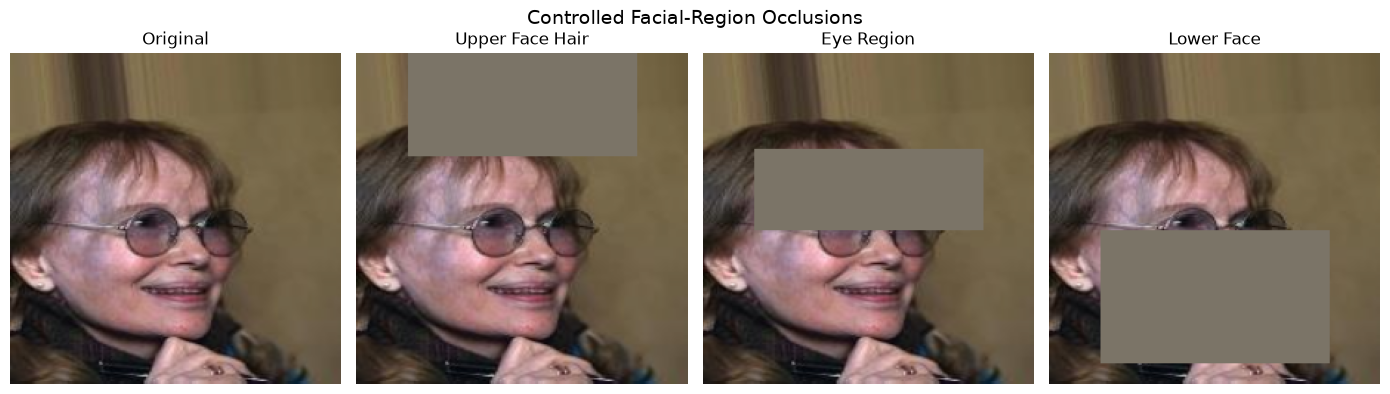

In [20]:
sample_index = int(
    selected_cam_samples["TP"]["sample_index"]
)

sample_tensor, _ = test_external_dataset[
    sample_index
]

fig, axes = plt.subplots(
    1,
    len(OCCLUSION_REGIONS) + 1,
    figsize=(14, 4)
)

# Original image
axes[0].imshow(
    denormalise_image(sample_tensor)
)
axes[0].set_title("Original")
axes[0].axis("off")


# Occluded versions
for plot_index, (region_name, region) in enumerate(
    OCCLUSION_REGIONS.items(),
    start=1
):
    occluded_tensor = occlude_tensor_region(
        sample_tensor,
        region
    )

    axes[plot_index].imshow(
        denormalise_image(occluded_tensor)
    )

    axes[plot_index].set_title(
        region_name.replace("_", " ").title()
    )

    axes[plot_index].axis("off")


fig.suptitle(
    "Controlled Facial-Region Occlusions",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [21]:
def evaluate_occlusion_sensitivity(
    model,
    dataset,
    audit_dataframe,
    regions,
    device
):
    """
    Measure how masking different facial regions changes confidence in
    each sample's original predicted class.
    """

    model.eval()

    records = []

    for sample_index in tqdm.tqdm(
        range(len(dataset)),
        desc="Running occlusion audit"
    ):
        image_tensor, _ = dataset[sample_index]

        audit_row = audit_dataframe.iloc[
            sample_index
        ]

        original_predicted_class = int(
            audit_row["predicted_label"]
        )

        original_confidence = float(
            audit_row["confidence"]
        )

        for region_name, region in regions.items():

            occluded_tensor = occlude_tensor_region(
                image_tensor,
                region
            )

            with torch.no_grad():
                logits = model(
                    occluded_tensor
                    .unsqueeze(0)
                    .to(device)
                )

                probabilities = torch.softmax(
                    logits,
                    dim=1
                )[0]

            occluded_probability = float(
                probabilities[
                    original_predicted_class
                ].cpu()
            )

            confidence_drop = (
                original_confidence
                - occluded_probability
            )

            records.append({
                "sample_index": sample_index,
                "error_type": audit_row["error_type"],
                "true_class": audit_row["true_class"],
                "predicted_class": audit_row["predicted_class"],
                "region": region_name,
                "original_confidence": original_confidence,
                "occluded_probability": occluded_probability,
                "confidence_drop": confidence_drop,
            })

    return pd.DataFrame(records)


external_occlusion_results = evaluate_occlusion_sensitivity(
    resnet_frozen,
    test_external_dataset,
    external_audit,
    OCCLUSION_REGIONS,
    device
)

external_occlusion_results.head()

Running occlusion audit: 100%|██████████| 300/300 [00:03<00:00, 83.90it/s]


,sample_index,error_type,true_class,predicted_class,region,original_confidence,occluded_probability,confidence_drop
0,0,TN,negative,negative,upper_face_hair,0.922684,0.946608,-0.023924
1,0,TN,negative,negative,eye_region,0.922684,0.080399,0.842285
2,0,TN,negative,negative,lower_face,0.922684,0.216157,0.706527
3,1,TN,negative,negative,upper_face_hair,0.991030,0.990878,0.000152
4,1,TN,negative,negative,eye_region,0.991030,0.351415,0.639615


In [22]:
occlusion_summary = (
    external_occlusion_results
    .groupby(
        ["error_type", "region"]
    )["confidence_drop"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        count="count"
    )
    .reset_index()
)

occlusion_summary

,error_type,region,mean,median,std,count
0,FN,eye_region,0.067630,-0.001665,0.290467,57
1,FN,lower_face,0.307893,0.309761,0.302189,57
2,FN,upper_face_hair,0.065817,0.017385,0.155967,57
3,FP,eye_region,-0.195774,-0.231916,0.162493,30
4,FP,lower_face,-0.027637,-0.018352,0.163627,30
5,FP,upper_face_hair,-0.060045,-0.012341,0.142148,30
6,TN,eye_region,0.625344,0.681206,0.233712,120
7,TN,lower_face,0.325549,0.273220,0.252341,120
8,TN,upper_face_hair,0.052018,0.017270,0.103620,120
9,TP,eye_region,0.139882,0.098720,0.225344,93


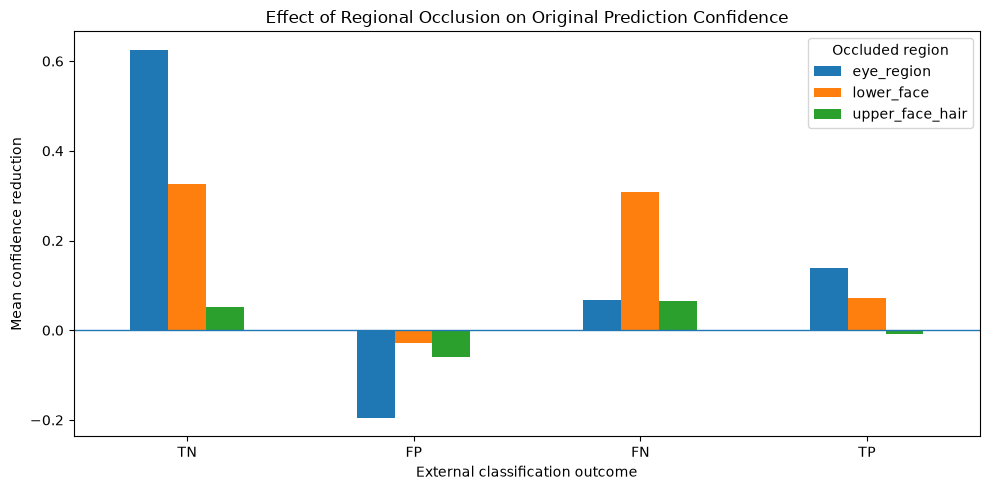

In [23]:
occlusion_plot = (
    external_occlusion_results
    .groupby(
        ["error_type", "region"]
    )["confidence_drop"]
    .mean()
    .unstack()
    .reindex(["TN", "FP", "FN", "TP"])
)

ax = occlusion_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.axhline(
    0,
    linewidth=1
)

ax.set_title(
    "Effect of Regional Occlusion on Original Prediction Confidence"
)

ax.set_xlabel(
    "External classification outcome"
)

ax.set_ylabel(
    "Mean confidence reduction"
)

ax.legend(
    title="Occluded region"
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 8.4 Preliminary occlusion findings

The regional occlusion experiment provides evidence that the external errors do not rely uniformly on the eyeglasses region.

For correctly classified samples, masking the eye region substantially affects the model's decision, consistent with the eye area containing valid evidence about the presence or absence of eyeglasses.

A different pattern is observed for the external errors. For false negatives, masking the lower face causes a substantially larger reduction in confidence in the incorrect negative prediction than masking the eye region. The median effect of eye-region occlusion on false negatives is approximately zero. This indicates that many incorrect negative decisions are being supported primarily by features outside the target region despite eyeglasses being visibly present.

For false positives, eye-region masking produces a negative mean confidence reduction: removing the eye region makes the incorrect positive prediction more confident. This suggests that the eye region often contains evidence opposing the erroneous prediction and that the false-positive decision is being driven by other image features.

These findings are consistent with **shortcut learning / spurious feature reliance**. However, the current masks differ in area, so an equal-area occlusion experiment is performed before drawing the final conclusion.

In [24]:
# Equal-area facial regions
#
# Each region has the same width and height so that differences in
# confidence change are attributable more directly to location rather
# than the number of pixels removed.
OCCLUSION_REGIONS_EQUAL = {
    "upper_face_hair": {
        "x_start": 35,
        "x_end": 190,
        "y_start": 10,
        "y_end": 65,
    },
    "eye_region": {
        "x_start": 35,
        "x_end": 190,
        "y_start": 65,
        "y_end": 120,
    },
    "lower_face": {
        "x_start": 35,
        "x_end": 190,
        "y_start": 120,
        "y_end": 175,
    },
}

region_areas = {
    region_name: (
        (region["x_end"] - region["x_start"])
        * (region["y_end"] - region["y_start"])
    )
    for region_name, region in OCCLUSION_REGIONS_EQUAL.items()
}

print("Occlusion areas:")
for region_name, area in region_areas.items():
    print(f"{region_name}: {area} pixels")

Occlusion areas:
upper_face_hair: 8525 pixels
eye_region: 8525 pixels
lower_face: 8525 pixels


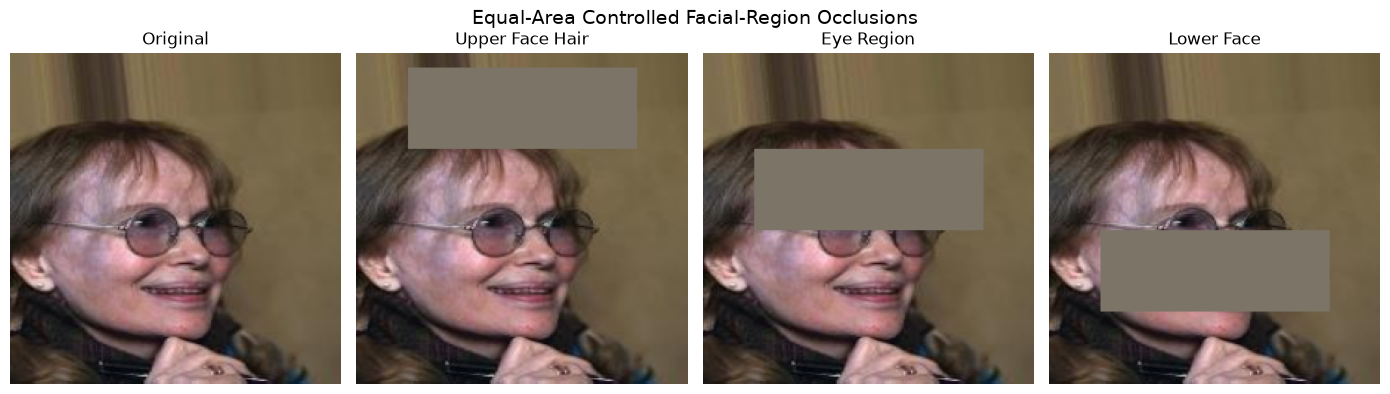

In [25]:
sample_index = int(
    selected_cam_samples["TP"]["sample_index"]
)

sample_tensor, _ = test_external_dataset[
    sample_index
]

fig, axes = plt.subplots(
    1,
    len(OCCLUSION_REGIONS_EQUAL) + 1,
    figsize=(14, 4)
)

# Original image
axes[0].imshow(
    denormalise_image(sample_tensor)
)
axes[0].set_title("Original")
axes[0].axis("off")


# Equal-area occluded versions
for plot_index, (region_name, region) in enumerate(
    OCCLUSION_REGIONS_EQUAL.items(),
    start=1
):
    occluded_tensor = occlude_tensor_region(
        sample_tensor,
        region
    )

    axes[plot_index].imshow(
        denormalise_image(occluded_tensor)
    )

    axes[plot_index].set_title(
        region_name.replace("_", " ").title()
    )

    axes[plot_index].axis("off")


fig.suptitle(
    "Equal-Area Controlled Facial-Region Occlusions",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [26]:
external_occlusion_equal = evaluate_occlusion_sensitivity(
    resnet_frozen,
    test_external_dataset,
    external_audit,
    OCCLUSION_REGIONS_EQUAL,
    device
)

equal_occlusion_summary = (
    external_occlusion_equal
    .groupby(
        ["error_type", "region"]
    )["confidence_drop"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        count="count"
    )
    .reset_index()
)

equal_occlusion_summary

Running occlusion audit: 100%|██████████| 300/300 [00:03<00:00, 78.42it/s]


,error_type,region,mean,median,std,count
0,FN,eye_region,0.067630,-0.001665,0.290467,57
1,FN,lower_face,0.256722,0.288302,0.318324,57
2,FN,upper_face_hair,0.082740,0.049434,0.150697,57
3,FP,eye_region,-0.195774,-0.231916,0.162493,30
4,FP,lower_face,-0.049701,-0.017776,0.158484,30
5,FP,upper_face_hair,-0.044928,-0.023778,0.132468,30
6,TN,eye_region,0.625344,0.681206,0.233712,120
7,TN,lower_face,0.340294,0.296515,0.244180,120
8,TN,upper_face_hair,0.029208,0.004396,0.079733,120
9,TP,eye_region,0.139882,0.098720,0.225344,93


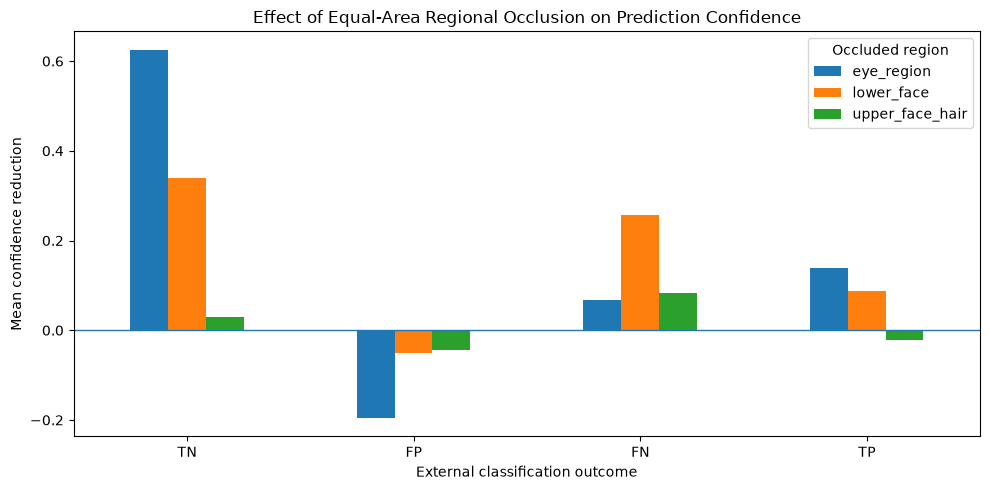

In [27]:
equal_occlusion_plot = (
    external_occlusion_equal
    .groupby(
        ["error_type", "region"]
    )["confidence_drop"]
    .mean()
    .unstack()
    .reindex(["TN", "FP", "FN", "TP"])
)

ax = equal_occlusion_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.axhline(0, linewidth=1)

ax.set_title(
    "Effect of Equal-Area Regional Occlusion on Prediction Confidence"
)

ax.set_xlabel(
    "External classification outcome"
)

ax.set_ylabel(
    "Mean confidence reduction"
)

ax.legend(
    title="Occluded region"
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [28]:
def evaluate_occlusion_with_flips(
    model,
    dataset,
    audit_dataframe,
    regions,
    device
):
    """
    Measure confidence changes and prediction flips after
    equal-area regional occlusion.
    """

    model.eval()
    records = []

    for sample_index in tqdm.tqdm(
        range(len(dataset)),
        desc="Running prediction-flip audit"
    ):
        image_tensor, true_label = dataset[sample_index]
        audit_row = audit_dataframe.iloc[sample_index]

        original_prediction = int(
            audit_row["predicted_label"]
        )

        original_confidence = float(
            audit_row["confidence"]
        )

        for region_name, region in regions.items():

            occluded_tensor = occlude_tensor_region(
                image_tensor,
                region
            )

            with torch.no_grad():
                logits = model(
                    occluded_tensor
                    .unsqueeze(0)
                    .to(device)
                )

                probabilities = torch.softmax(
                    logits,
                    dim=1
                )[0]

            occluded_prediction = int(
                torch.argmax(probabilities).cpu()
            )

            original_class_probability = float(
                probabilities[
                    original_prediction
                ].cpu()
            )

            records.append({
                "sample_index": sample_index,
                "error_type": audit_row["error_type"],
                "true_label": int(true_label),
                "original_prediction": original_prediction,
                "region": region_name,
                "confidence_drop": (
                    original_confidence
                    - original_class_probability
                ),
                "prediction_flipped": (
                    occluded_prediction != original_prediction
                ),
                "correct_after_occlusion": (
                    occluded_prediction == int(true_label)
                ),
            })

    return pd.DataFrame(records)

In [29]:
external_occlusion_flip_results = evaluate_occlusion_with_flips(
    resnet_frozen,
    test_external_dataset,
    external_audit,
    OCCLUSION_REGIONS_EQUAL,
    device
)

Running prediction-flip audit: 100%|██████████| 300/300 [00:03<00:00, 81.12it/s]


In [30]:
flip_summary = (
    external_occlusion_flip_results
    .groupby(
        ["error_type", "region"]
    )
    .agg(
        flip_rate=("prediction_flipped", "mean"),
        correct_after_occlusion_rate=("correct_after_occlusion", "mean"),
        count=("sample_index", "count"),
    )
    .reset_index()
)

flip_summary

,error_type,region,flip_rate,correct_after_occlusion_rate,count
0,FN,eye_region,0.228070,0.228070,57
1,FN,lower_face,0.438596,0.438596,57
2,FN,upper_face_hair,0.175439,0.175439,57
3,FP,eye_region,0.033333,0.033333,30
4,FP,lower_face,0.133333,0.133333,30
5,FP,upper_face_hair,0.066667,0.066667,30
6,TN,eye_region,0.800000,0.200000,120
7,TN,lower_face,0.400000,0.600000,120
8,TN,upper_face_hair,0.033333,0.966667,120
9,TP,eye_region,0.172043,0.827957,93


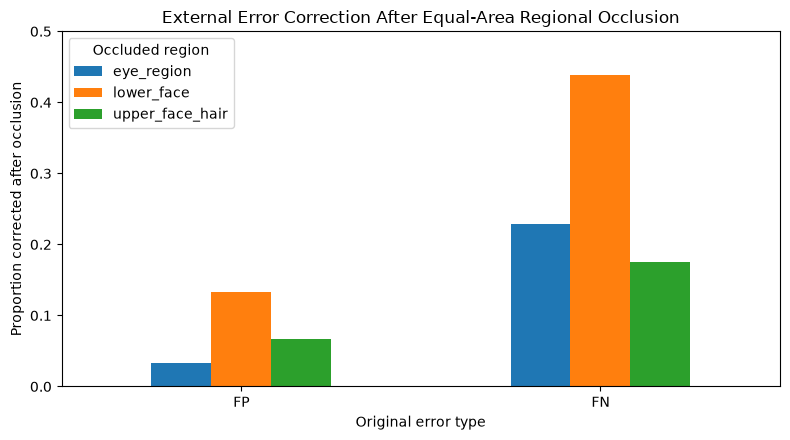

In [31]:
error_correction_plot = (
    external_occlusion_flip_results[
        external_occlusion_flip_results["error_type"].isin(["FP", "FN"])
    ]
    .groupby(
        ["error_type", "region"]
    )["correct_after_occlusion"]
    .mean()
    .unstack()
    .reindex(["FP", "FN"])
)

ax = error_correction_plot.plot(
    kind="bar",
    figsize=(8, 4.5)
)

ax.set_title(
    "External Error Correction After Equal-Area Regional Occlusion"
)

ax.set_xlabel(
    "Original error type"
)

ax.set_ylabel(
    "Proportion corrected after occlusion"
)

ax.set_ylim(0, 0.5)

ax.legend(
    title="Occluded region"
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Audit Diagnosis

### Technical diagnosis

The Case 2 deployment failure is most consistent with **shortcut learning caused by spurious correlations in the development distribution**.

Although the model was trained to classify eyeglasses, the audit shows that its decisions are not based exclusively on evidence from the eye / eyeglasses region. The network also relies on facial characteristics outside the target region that were apparently predictive of eyeglasses status in the internal development data.

This shortcut produces near-perfect internal performance but fails when those relationships change across users in the external deployment population.

### Evidence

The diagnosis is supported by several independent findings:

1. **Large generalisation gap:** accuracy decreases from **98.67% internally to 71.00% externally**, increasing from only 4 errors to 87 errors.

2. **Class balance does not explain the failure:** both datasets contain exactly 150 positive and 150 negative samples.

3. **Both types of error increase substantially:** the external set contains **30 false positives and 57 false negatives**, while positive-class recall decreases from **97.33% to 62.00%**.

4. **CAM reveals inappropriate localisation during errors:** correct predictions can focus strongly on the eye / eyeglasses region, whereas high-confidence incorrect predictions can obtain substantial evidence from broader facial regions.

5. **Equal-area occlusion provides direct perturbation evidence:** for the 57 external false negatives, removing the lower-face region corrects **43.86%** of predictions, almost twice the **22.81%** corrected by removing the actual eye region. For false positives, lower-face removal corrects **13.33%**, compared with only **3.33%** after eye-region removal.

6. **Correct predictions provide an important control:** eye-region removal changes **80.0% of true-negative predictions**, while upper-face / hair removal changes only **3.3%**. The model is therefore capable of using relevant eye-region evidence, but many external failures are driven disproportionately by non-target information.

### Conclusion

The near-perfect internal accuracy therefore overstates the model's robustness. The evidence indicates that the development distribution allowed the classifier to exploit **non-causal facial cues correlated with eyeglasses status**. When these correlations differ in deployment, the learned shortcut becomes unreliable and produces user-dependent failures.

## 10. Recommendations

### 1. Audit and rebalance the development dataset
Identify facial and demographic attributes that are correlated with the `Eyeglasses` target in the training and validation data. Ensure that eyeglasses-positive and eyeglasses-negative examples are adequately represented across relevant user subgroups and combinations of appearance characteristics.

Simply collecting more images is insufficient if the same confounding relationships remain present.

### 2. Construct subgroup-aware validation and external test sets
Future evaluation should report performance separately across relevant user subgroups rather than relying only on aggregate accuracy.

Accuracy, recall, false-positive rate and false-negative rate should be checked across these groups before deployment so that shortcut-dependent performance cannot be hidden by a favourable overall test distribution.

### 3. Reduce dependence on non-target facial information
During redevelopment, investigate approaches that encourage the classifier to rely more directly on the eye / eyeglasses region. Possible approaches include targeted cropping, region-aware augmentation, and improving representation of samples that break existing target–appearance correlations.

### 4. Repeat explainability and perturbation audits before redeployment
CAM / saliency inspection and controlled occlusion tests should be repeated on the revised model. A successful redevelopment should show stronger and more consistent dependence on the eyeglasses region and substantially less sensitivity to unrelated facial regions.

### Limitation
The supplied Case 2 data do not include explicit subgroup metadata. The audit therefore establishes **spurious reliance on non-target facial characteristics**, but does not assign the observed shortcut to a specific demographic attribute. Confirming the precise confounder would require appropriate dataset annotations or metadata.